<a href="https://colab.research.google.com/github/Omkar210/Statistics-and-ML/blob/main/Day21.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import warnings
warnings.filterwarnings("ignore")
pd.set_option('display.max_columns', None)
from numpy import random
from collections import Counter
from numpy.linalg import inv
from numpy.linalg import eig
import matplotlib
from matplotlib import pyplot as plt
import seaborn as sns
import pylab
from pylab import legend
from pylab import plot, show, title, xlabel, ylabel
import scipy
from scipy import stats
from scipy.stats import binom,poisson,norm,t,expon,f
from sklearn.model_selection import train_test_split
import statsmodels
from statsmodels import stats
from statsmodels.stats import weightstats as ssw
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import statsmodels.stats
from statsmodels.stats.proportion import proportions_ztest
from scipy.stats import chisquare
from scipy.stats import chi2_contingency
from statsmodels.stats import rates
from statsmodels.stats.rates import test_poisson
from statsmodels.stats.rates import test_poisson_2indep
from scipy.stats import chi2
from scipy.stats import f
import statsmodels.api as sm
from statsmodels.formula.api import ols
import statsmodels.stats.multicomp
import sklearn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import StandardScaler
from statsmodels.stats.outliers_influence import variance_inflation_factor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
# from category_encoders import BinaryEncoder
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.metrics import log_loss
from statsmodels.discrete.discrete_model import MNLogit
from statsmodels.miscmodels.ordinal_model import OrderedModel
from sklearn.metrics import roc_curve
from sklearn.metrics import roc_auc_score
import statsmodels.formula.api as smf
from statsmodels.discrete.discrete_model import Poisson as psn
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import r2_score
import os
print(os.getcwd())
os.chdir('/content/drive/MyDrive/CDAC')
os.getcwd()

/content


'/content/drive/MyDrive/CDAC'

# Random Forest

- Random forest is the group of certain amount of decision trees.
- In Categorical Data, Decision in random forest will be decided based on Voting/Majority.
- In Continuous Data, We take the mean of reponses given by all decision tree.
- Random forest will have all hyperparameter of decision tree plus n_estimators.

In [2]:
df = pd.read_excel('CDAC_DataBook.xlsx', sheet_name = 'diabetes')
df = df[['Glucose','BloodPressure','Age','DietType','Outcome']]

diet_dummy = pd.get_dummies(df.DietType, drop_first=True, prefix='Diet').astype(int)
df = df.drop('DietType', axis=1)
df = pd.concat([df,diet_dummy], axis=1)

x= df.drop('Outcome', axis=1)  # column of predictors
y= df.Outcome   # column of response

x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=20)

dtc = DecisionTreeClassifier()
dtc.fit(x_train,y_train)

y_pred=dtc.predict(x_test)
from sklearn.metrics import confusion_matrix,classification_report

print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

# hyperparameter tuning

param={
    'criterion':['gini','entropy', 'log_loss'],
    'splitter':['best','random'],
    'max_depth':[1,2,3,4,5,6,7],
    'max_features':['auto','sqrt','log2'],
    'min_samples_split' : [2,3,4,5],
    'min_samples_leaf' : [2,3,4,5]
}

from sklearn.model_selection import GridSearchCV
grid=GridSearchCV(dtc,param_grid=param,cv=5,scoring='accuracy')
grid.fit(x_train,y_train)
grid.best_params_

dtc = DecisionTreeClassifier(criterion= 'gini',
 max_depth= 5,
 max_features= 'sqrt',
 min_samples_leaf= 5,
 min_samples_split= 2,
 splitter= 'best')

dtc.fit(x_train,y_train)
print(dtc.score(x_train, y_train))   # training data accuracy
print(dtc.score(x_test, y_test))    # test data accuracy

y_pred = dtc.predict(x_test)
print(confusion_matrix(y_test,y_pred))

[[84 17]
 [17 36]]
              precision    recall  f1-score   support

           0       0.83      0.83      0.83       101
           1       0.68      0.68      0.68        53

    accuracy                           0.78       154
   macro avg       0.76      0.76      0.76       154
weighted avg       0.78      0.78      0.78       154

1.0
0.7792207792207793
0.8876221498371335
0.8571428571428571
[[94  7]
 [15 38]]


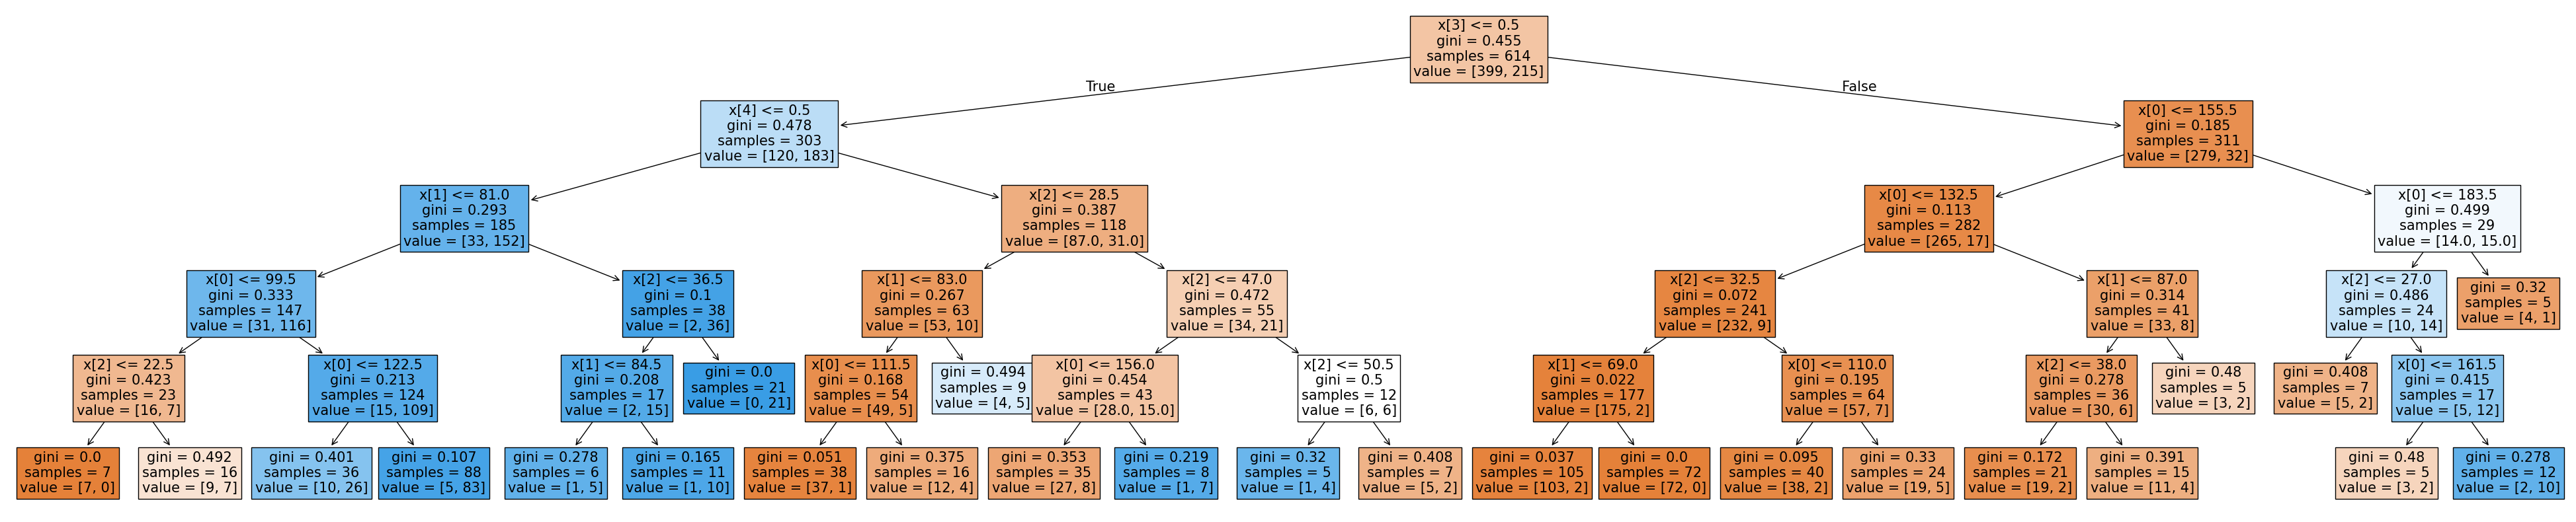

In [7]:
from sklearn import tree
plt.figure(figsize=(50,10))
tree.plot_tree(dtc,filled=True,fontsize=15)
plt.show()

In [31]:
from sklearn.ensemble import RandomForestClassifier
rfc = RandomForestClassifier(n_estimators=50,max_depth=4,bootstrap=False)
model = rfc.fit(x_train,y_train)
model

RandomForestClassifier(bootstrap=False, max_depth=4, n_estimators=50)

In [32]:
print(model.score(x_train, y_train))   # training data accuracy
print(model.score(x_test, y_test))    # test data accuracy

0.9087947882736156
0.8831168831168831
